In [1]:
from rdkit import Chem
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ShuffleSplit, GridSearchCV, cross_val_score, cross_validate
import os
import glob
from scipy.stats import norm
import math
import random

In [2]:
T_0 = pd.read_excel('URAT11210y.xlsx')
T=np.array(T_0)
from sklearn import preprocessing  
print(T)  
print(len(T))


[[9.  ]
 [8.7 ]
 [8.7 ]
 [8.52]
 [8.4 ]
 [8.22]
 [8.15]
 [8.15]
 [8.1 ]
 [8.1 ]
 [8.  ]
 [8.  ]
 [8.  ]
 [8.  ]
 [7.96]
 [7.92]
 [7.92]
 [7.92]
 [7.92]
 [7.92]
 [7.89]
 [7.85]
 [7.82]
 [7.82]
 [7.82]
 [7.82]
 [7.82]
 [7.82]
 [7.8 ]
 [7.77]
 [7.75]
 [7.75]
 [7.75]
 [7.75]
 [7.75]
 [7.75]
 [7.75]
 [7.72]
 [7.72]
 [7.72]
 [7.72]
 [7.72]
 [7.71]
 [7.7 ]
 [7.68]
 [7.68]
 [7.67]
 [7.66]
 [7.66]
 [7.64]
 [7.64]
 [7.64]
 [7.64]
 [7.62]
 [7.62]
 [7.62]
 [7.62]
 [7.62]
 [7.6 ]
 [7.6 ]
 [7.58]
 [7.58]
 [7.58]
 [7.57]
 [7.57]
 [7.55]
 [7.54]
 [7.54]
 [7.54]
 [7.52]
 [7.52]
 [7.52]
 [7.52]
 [7.51]
 [7.51]
 [7.5 ]
 [7.5 ]
 [7.47]
 [7.47]
 [7.47]
 [7.47]
 [7.46]
 [7.46]
 [7.46]
 [7.46]
 [7.44]
 [7.43]
 [7.43]
 [7.43]
 [7.43]
 [7.43]
 [7.42]
 [7.42]
 [7.41]
 [7.41]
 [7.4 ]
 [7.39]
 [7.39]
 [7.38]
 [7.38]
 [7.38]
 [7.38]
 [7.37]
 [7.37]
 [7.37]
 [7.36]
 [7.35]
 [7.35]
 [7.34]
 [7.33]
 [7.31]
 [7.3 ]
 [7.3 ]
 [7.3 ]
 [7.3 ]
 [7.29]
 [7.29]
 [7.28]
 [7.28]
 [7.28]
 [7.28]
 [7.28]
 [7.28]
 [7.28]
 [7.28]


In [3]:
#读入特征    1000种描述符数据 
X=pd.read_excel('URAT11210x.xlsx')
X=np.array(X)
from sklearn import preprocessing  
print(X)
print(len(X[0]))
print(len(X))

[[ 0  1  1 ...  0  0 19]
 [ 1  0  1 ...  0  0 18]
 [ 0  0  0 ...  0  0 14]
 ...
 [ 1  1  0 ...  0  0 18]
 [ 0  1  0 ...  0  0 19]
 [ 1  0  1 ...  0  0 24]]
1331
783


In [20]:
from sklearn.model_selection import train_test_split
X_train,  X_test,  T_train,  T_test  =  train_test_split(X,T,test_size=0.200,random_state=51)

In [21]:
test_y = T_test
test_x = X_test

In [22]:
cv_x = X_train
cv_y = T_train

In [23]:
import lightgbm as lgb  
from sklearn.model_selection import KFold  
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  
import numpy as np  
   
  
cv_scores = []  
train_r2_scores = []  
train_mae_scores = []  
train_rmse_scores = []  
test_scores = []  
MAE_scores = []  
RMSE_scores = []  
  
kf = KFold(n_splits=10, shuffle=True, random_state=725)  
for train_ix, valid_ix in kf.split(cv_x):  
    train_x = cv_x[train_ix]  
    valid_x = cv_x[valid_ix]  
    train_y = cv_y[train_ix]  
    valid_y = cv_y[valid_ix]  
      
    clf = XGBRegressor(
    n_estimators=300,       # 增加树的数量，通常100-1000之间
    learning_rate=0.09,     # 降低学习率，通常0.01-0.3之间
    max_depth=5,            # 限制树的最大深度，通常3-10之间
    min_child_weight=1,     # 控制叶子节点最小样本权重和
    subsample=0.8,          # 样本采样比例
    colsample_bytree=0.8,   # 特征采样比例
    n_jobs=-1,              # 使用所有CPU核心
    random_state=42,         # 随机种子
    reg = 0.1,       # L2正则化
    alpha = 0.4,     # L1正则化
)

    clf.fit(train_x, train_y)  
      
    # 训练集预测  
    train_predictions = clf.predict(train_x)  
      
    # 计算训练集的R2, MAE, RMSE  
    train_r2 = r2_score(train_y, train_predictions)  
    train_mae = mean_absolute_error(train_y, train_predictions)  
    train_rmse = np.sqrt(mean_squared_error(train_y, train_predictions))  
      
    # 存储训练集的指标  
    train_r2_scores.append(train_r2)  
    train_mae_scores.append(train_mae)  
    train_rmse_scores.append(train_rmse)  
      
    # 验证集预测  
    val_results = clf.predict(valid_x)  
      
    # 计算验证集的R2  
    valid_score = r2_score(valid_y, val_results)  
    cv_scores.append(valid_score)  
      
    # 假设 test_x 和 test_y 已经被定义，进行测试集预测  
    test_results = clf.predict(test_x)  
    test_score = r2_score(test_y, test_results)  
    test_scores.append(test_score)  
      
    # 计算测试集的MAE和RMSE  
    mae_score = mean_absolute_error(test_y, test_results)  
    MAE_scores.append(mae_score)  
      
    rmse_score = np.sqrt(mean_squared_error(test_y, test_results))  
    RMSE_scores.append(rmse_score)  
  
# 输出训练集的结果  
print('Training R2 scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(train_r2_scores), np.std(train_r2_scores)))  
print('Training MAE scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(train_mae_scores), np.std(train_mae_scores)))  
print('Training RMSE scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(train_rmse_scores), np.std(train_rmse_scores)))  
  
# 输出验证集的结果  
print('Cross-validation R2 scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(cv_scores), np.std(cv_scores)))  
  
# 输出测试集的结果  
print('Test R2 scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(test_scores), np.std(test_scores)))  
print('Test MAE scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(MAE_scores), np.std(MAE_scores)))  
print('Test RMSE scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(RMSE_scores), np.std(RMSE_scores)))

/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [00:30:24] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [00:30:25] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [00:30:27] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [00:30:28] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [00:30:29] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not us

Training R2 scores: mean = 0.983, std = 0.002
Training MAE scores: mean = 0.072, std = 0.002
Training RMSE scores: mean = 0.126, std = 0.006
Cross-validation R2 scores: mean = 0.566, std = 0.101
Test R2 scores: mean = 0.743, std = 0.027
Test MAE scores: mean = 0.345, std = 0.018
Test RMSE scores: mean = 0.470, std = 0.025


In [24]:
print('test: {:.3f}+-{:.3f}'.format(np.array(test_scores).mean(), np.array(test_scores).std()))
print('test: {:.3f}+-{:.3f}'.format(np.array(MAE_scores).mean(), np.array(MAE_scores).std()))
print('test: {:.3f}+-{:.3f}'.format(np.array(RMSE_scores).mean(), np.array(RMSE_scores).std()))

test: 0.743+-0.027
test: 0.345+-0.018
test: 0.470+-0.025


In [4]:
from sklearn.model_selection import train_test_split
X_train,  X_test,  T_train,  T_test  =  train_test_split(X,T,test_size=0.20,random_state=51)

In [5]:
from xgboost import XGBRegressor

clf = XGBRegressor(
    n_estimators=300,       # 增加树的数量，通常100-1000之间
    learning_rate=0.09,     # 降低学习率，通常0.01-0.3之间
    max_depth=5,            # 限制树的最大深度，通常3-10之间
    min_child_weight=1,     # 控制叶子节点最小样本权重和
    subsample=0.8,          # 样本采样比例
    colsample_bytree=0.8,   # 特征采样比例
    n_jobs=-1,              # 使用所有CPU核心
    random_state=42,         # 随机种子
    reg = 0.1,       # L2正则化
    alpha = 0.4,     # L1正则化
)
clf.fit(X_train, T_train)

/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [00:16:02] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not used.

  warnings.warn(smsg, UserWarning)


XGBRegressor(alpha=0.4, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.09, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, ...)

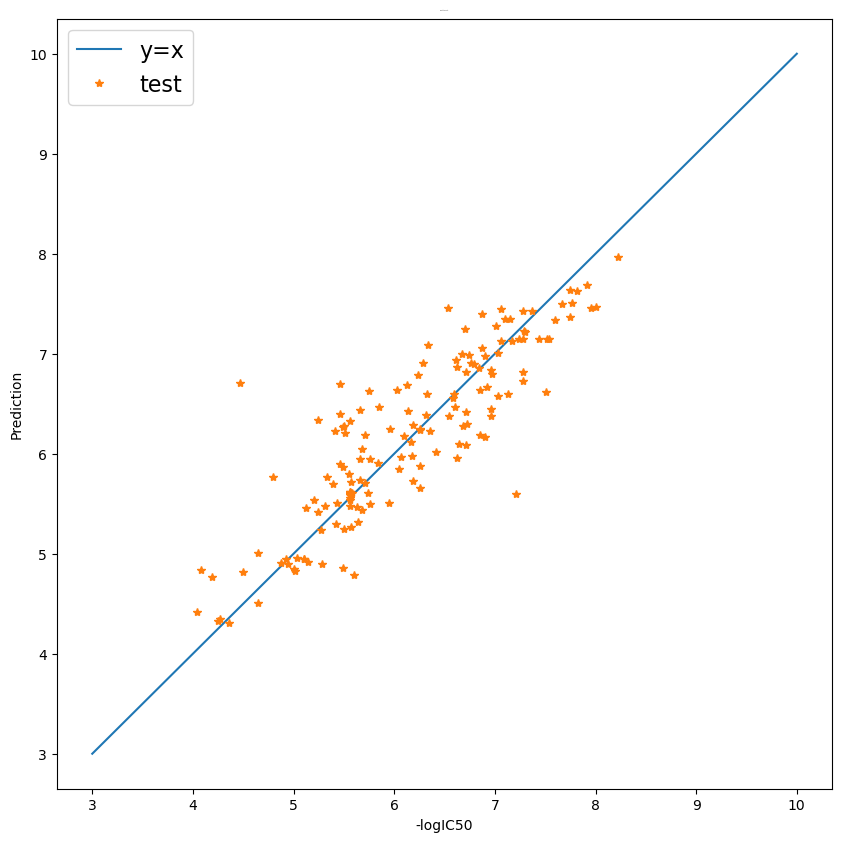

In [6]:
import matplotlib.pyplot as plt

y_true_test=T_test
y_pred_test=clf.predict(X_test)
legend=["y=x","test"]
fig = plt.figure(figsize=(10,10))
plt.plot(range(3,11), range(3,11),"-")
plt.plot(y_true_test, y_pred_test,"*")
plt.xlabel("-logIC50", fontsize=10)
plt.ylabel('Prediction', fontsize=10)
plt.legend(legend,fontsize=16)
plt.title('Scatter Plot', fontsize=1)
plt.show()

In [7]:
from sklearn.metrics import r2_score
print ("测试集 r^2 score",r2_score(T_test,y_pred_test))

测试集 r^2 score 0.7509055600000925


In [8]:
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_true=T_test
y_pred=clf.predict(X_test)
mean_absolute_error(y_true, y_pred)
#np.sqrt(mean_squared_error(y_true,y_pred))

0.3359772803677116

In [9]:
np.sqrt(mean_squared_error(y_true,y_pred))

0.4632305214414408

In [10]:
y_pred_test=clf.predict(X_test)
df=pd.DataFrame(y_pred_test)
df.to_csv("./IC50/resulttestPreLGBG1.csv",index=False,header=False)
y_true=T_test
df=pd.DataFrame(y_true)
df.to_csv("./IC50/resulttestTrueLGBG1.csv",index=False,header=False)

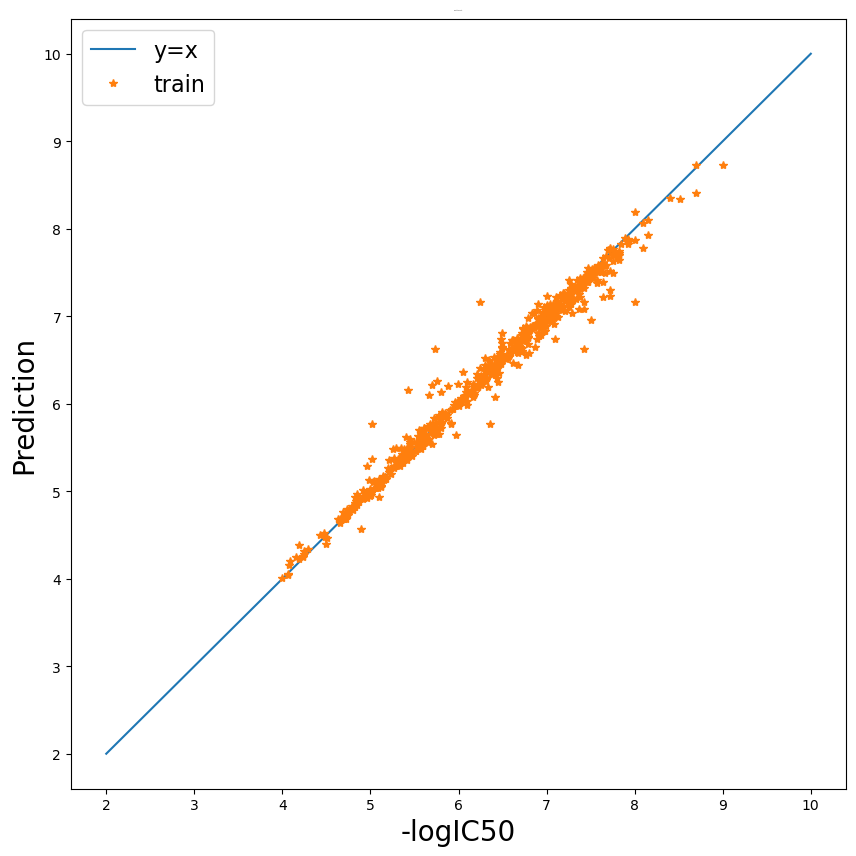

In [11]:
#查看散点图
import matplotlib.pyplot as plt
y_true_train=T_train
y_pred_train=clf.predict(X_train)

legend=["y=x","train"]
fig = plt.figure(figsize=(10,10))
plt.plot(range(2,11), range(2,11),"-")
plt.plot(y_true_train, y_pred_train,"*")
plt.xlabel("-logIC50", fontsize=20)
plt.ylabel('Prediction', fontsize=20)
plt.legend(legend,fontsize=16)
plt.title('Scatter Plot', fontsize=1)
plt.show()

In [12]:
from sklearn.metrics import r2_score
print ("训练集 r^2 score",r2_score(T_train,y_pred_train))

训练集 r^2 score 0.9804015797690828


In [13]:
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_true=T_train
y_pred=clf.predict(X_train)
mean_absolute_error(y_true, y_pred)
#np.sqrt(mean_squared_error(y_true,y_pred))

0.07757273290103996

In [14]:
np.sqrt(mean_squared_error(y_true,y_pred))

0.13461610504784202

In [15]:
print("整体",clf.score(X,T))

整体 0.937163733014918


In [16]:
y_pred_train=clf.predict(X_train)
df=pd.DataFrame(y_pred_train)
df.to_csv("./IC50/resulttrainPreLGBG1.csv",index=False,header=False)
y_true=T_train
df=pd.DataFrame(y_true)
df.to_csv("./IC50/resulttrainTrueLGBG1.csv",index=False,header=False)